# Warehouse Order Volume Forecasting with Google TimesFM

This notebook implements an end-to-end **warehouse order volume forecasting** workflow for logistics operations.

## Problem

Fulfillment centers receive variable daily order volumes. Managers must decide:

- workforce size
- picking capacity
- packing station allocation

## Objective

From historical daily order data, forecast future order volume for:

- next day
- next week
- next month

Then convert forecasts into actionable warehouse plans.


## What You Will Learn

1. Download a production-grade e-commerce operations dataset from the web.
2. Build and validate a daily warehouse order time series.
3. Detect and handle right-censoring (partial end-of-history data).
4. Train/evaluate TimesFM with calendar covariates.
5. Compare against strong baselines.
6. Produce operations planning outputs for workforce, picking, and packing.


In [1]:
from __future__ import annotations

import math
import os
import subprocess
import zipfile
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

SEED = 42
np.random.seed(SEED)

# Robust CPU-first defaults for heterogeneous local environments.
os.environ.setdefault('CUDA_VISIBLE_DEVICES', '')
os.environ.setdefault('JAX_PLATFORMS', 'cpu')

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
DATA_DIR = PROJECT_ROOT / 'data' / 'warehouse_orders'
RAW_DIR = DATA_DIR / 'raw'
ART_DIR = PROJECT_ROOT / 'artifacts' / 'warehouse_order_volume_timesfm'

RAW_DIR.mkdir(parents=True, exist_ok=True)
ART_DIR.mkdir(parents=True, exist_ok=True)

ORDERS_CSV = RAW_DIR / 'olist_orders_dataset.csv'

print('Project root:', PROJECT_ROOT)
print('Orders CSV:', ORDERS_CSV)
print('Artifacts dir:', ART_DIR)

Project root: /home/ahmad/AI/Github/google-TimesFM-implementation
Orders CSV: /home/ahmad/AI/Github/google-TimesFM-implementation/data/warehouse_orders/raw/olist_orders_dataset.csv
Artifacts dir: /home/ahmad/AI/Github/google-TimesFM-implementation/artifacts/warehouse_order_volume_timesfm


## 1) Download Data from Web

Dataset: **Kaggle - `olistbr/brazilian-ecommerce`**

Why this dataset is production-grade for logistics forecasting:

- Real transactional e-commerce order flow
- Rich operational timestamps per order lifecycle
- Sufficient daily history for weekly/monthly demand signals

If local files already exist, download is skipped.


In [2]:
def ensure_dataset(orders_csv: Path) -> Path:
    if orders_csv.exists():
        print(f'Found existing file: {orders_csv}')
        return orders_csv

    zip_path = RAW_DIR / 'brazilian-ecommerce.zip'
    cmd = [
        'kaggle',
        'datasets',
        'download',
        '-d',
        'olistbr/brazilian-ecommerce',
        '-p',
        str(RAW_DIR),
        '--force',
    ]

    try:
        print('Downloading dataset from Kaggle...')
        subprocess.run(cmd, check=True, capture_output=True, text=True)
    except Exception as exc:
        raise RuntimeError(
            'Failed to download Kaggle dataset. Configure Kaggle API credentials or place '
            f'olist_orders_dataset.csv at {orders_csv}.'
        ) from exc

    if zip_path.exists():
        with zipfile.ZipFile(zip_path, 'r') as zf:
            zf.extractall(RAW_DIR)

    if not orders_csv.exists():
        raise FileNotFoundError(f'Expected file not found after download: {orders_csv}')

    return orders_csv


orders_csv = ensure_dataset(ORDERS_CSV)
orders_csv

Found existing file: /home/ahmad/AI/Github/google-TimesFM-implementation/data/warehouse_orders/raw/olist_orders_dataset.csv


PosixPath('/home/ahmad/AI/Github/google-TimesFM-implementation/data/warehouse_orders/raw/olist_orders_dataset.csv')

## 2) Build Daily Order Volume Series

Input table: `olist_orders_dataset.csv`

We use `order_purchase_timestamp` as the demand signal timestamp and aggregate to daily order count.


In [3]:
raw_orders = pd.read_csv(orders_csv, parse_dates=['order_purchase_timestamp'])

print('Raw shape:', raw_orders.shape)
print('Columns:', list(raw_orders.columns))
print('Date range (raw):', raw_orders['order_purchase_timestamp'].min(), '->', raw_orders['order_purchase_timestamp'].max())
print('Missing purchase timestamps:', int(raw_orders['order_purchase_timestamp'].isna().sum()))
print('Duplicate order_id rows:', int(raw_orders['order_id'].duplicated().sum()))

orders = raw_orders.dropna(subset=['order_purchase_timestamp']).copy()
orders['date'] = orders['order_purchase_timestamp'].dt.floor('D')

daily_orders = (
    orders.groupby('date', as_index=False)['order_id']
    .nunique()
    .rename(columns={'order_id': 'orders'})
    .sort_values('date')
)

print('Daily rows:', len(daily_orders))
print('Daily date range:', daily_orders['date'].min(), '->', daily_orders['date'].max())

daily_orders.head()

Raw shape: (99441, 8)
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
Date range (raw): 2016-09-04 21:15:19 -> 2018-10-17 17:30:18
Missing purchase timestamps: 0
Duplicate order_id rows: 0
Daily rows: 634
Daily date range: 2016-09-04 00:00:00 -> 2018-10-17 00:00:00


,date,orders
0,2016-09-04,1
1,2016-09-05,1
2,2016-09-13,1
3,2016-09-15,1
4,2016-10-02,1


In [4]:
# Fill missing calendar days with zero to create regular daily frequency.
full_dates = pd.date_range(daily_orders['date'].min(), daily_orders['date'].max(), freq='D')
series_df = (
    daily_orders
    .set_index('date')
    .reindex(full_dates)
    .fillna(0.0)
    .rename_axis('date')
    .reset_index()
)
series_df['orders'] = series_df['orders'].astype(np.float32)

print('Regularized rows:', len(series_df))
print('Any missing values:', bool(series_df['orders'].isna().any()))

series_df.tail()

Regularized rows: 774
Any missing values: False


,date,orders
769,2018-10-13,0.0
770,2018-10-14,0.0
771,2018-10-15,0.0
772,2018-10-16,1.0
773,2018-10-17,1.0


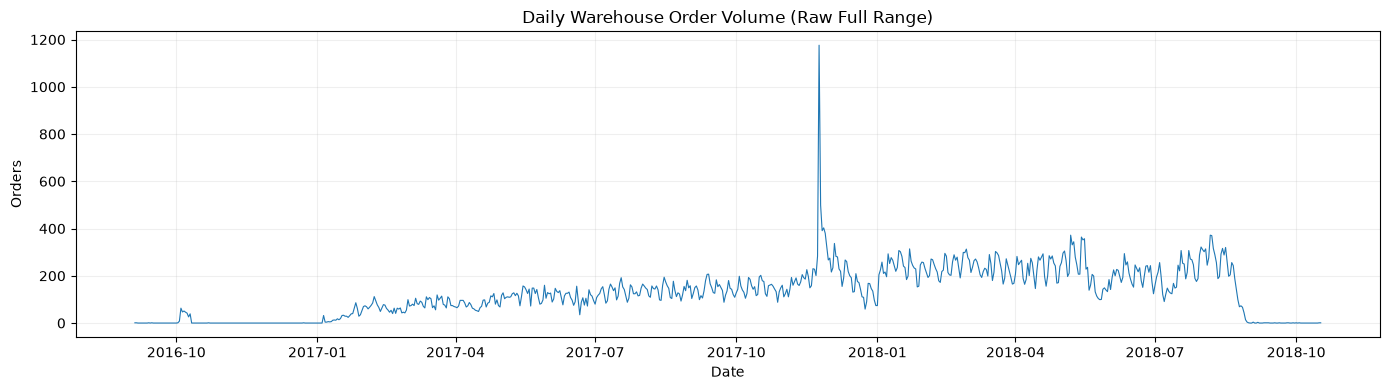

In [5]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(series_df['date'], series_df['orders'], lw=0.8)
ax.set_title('Daily Warehouse Order Volume (Raw Full Range)')
ax.set_ylabel('Orders')
ax.set_xlabel('Date')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 3) Data Quality Guard: Detect Right-Censoring at Series End

Operational datasets often have incomplete final days/weeks due delayed ingestion.

We detect sudden end-of-series collapse using:

- trailing 14-day mean
- previous 90-day mean
- collapse ratio threshold (`< 0.25`)

If collapse is detected, we cut the training history before this unstable tail.


In [6]:
def detect_censoring_cutoff(
    df: pd.DataFrame,
    ratio_threshold: float = 0.25,
    lookback_days: int = 180,
) -> pd.Timestamp | None:
    ts = df.copy().sort_values('date').reset_index(drop=True)
    ts['m14'] = ts['orders'].rolling(14, min_periods=14).mean()
    ts['m90_prev'] = ts['orders'].shift(14).rolling(90, min_periods=90).mean()
    ts['ratio'] = ts['m14'] / (ts['m90_prev'] + 1e-6)

    eval_start = ts['date'].max() - pd.Timedelta(days=lookback_days)
    tail = ts[(ts['date'] >= eval_start) & ts['ratio'].notna()].copy()
    candidates = tail[tail['ratio'] < ratio_threshold]
    if candidates.empty:
        return None

    collapse_start = candidates['date'].iloc[0]
    return collapse_start - pd.Timedelta(days=1)


cutoff_date = detect_censoring_cutoff(series_df, ratio_threshold=0.25, lookback_days=180)
if cutoff_date is None:
    stable_series = series_df.copy()
    print('No right-censoring collapse detected; using full history.')
else:
    stable_series = series_df[series_df['date'] <= cutoff_date].copy()
    print('Detected right-censoring collapse. Using cutoff date:', cutoff_date.date())

# Guardrail: never let auto-cutoff shrink the dataset too aggressively.
MIN_TRAIN_DAYS = 365
if len(stable_series) < MIN_TRAIN_DAYS:
    print('Stable history too short after cutoff; reverting to full history.')
    stable_series = series_df.copy()

print('Stable series rows:', len(stable_series))
print('Stable date range:', stable_series['date'].min(), '->', stable_series['date'].max())
print('Latest 7 stable days:', stable_series['orders'].tail(7).tolist())
stable_series.tail()

Detected right-censoring collapse. Using cutoff date: 2018-09-03
Stable series rows: 730
Stable date range: 2016-09-04 00:00:00 -> 2018-09-03 00:00:00
Latest 7 stable days: [44.0, 14.0, 4.0, 1.0, 0.0, 0.0, 4.0]


,date,orders
725,2018-08-30,4.0
726,2018-08-31,1.0
727,2018-09-01,0.0
728,2018-09-02,0.0
729,2018-09-03,4.0


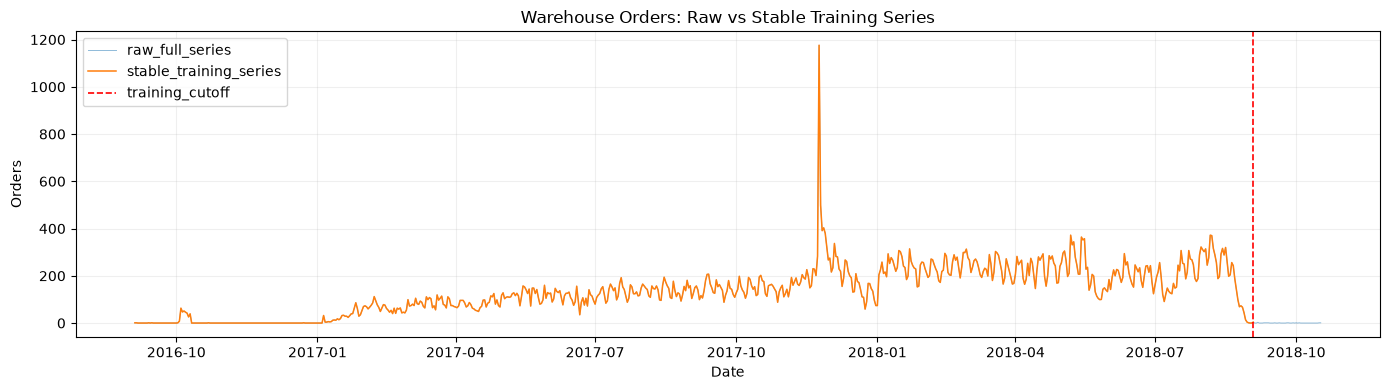

In [7]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(series_df['date'], series_df['orders'], lw=0.7, alpha=0.5, label='raw_full_series')
ax.plot(stable_series['date'], stable_series['orders'], lw=1.1, label='stable_training_series')
if cutoff_date is not None:
    ax.axvline(cutoff_date, color='red', linestyle='--', lw=1.2, label='training_cutoff')
ax.set_title('Warehouse Orders: Raw vs Stable Training Series')
ax.set_ylabel('Orders')
ax.set_xlabel('Date')
ax.grid(alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()

## 4) Forecast Configuration

- `context_len = 180` days
- `max_horizon = 30` days
- Evaluation horizons: `1, 7, 14, 30`
- Rolling anchors for robust backtesting

Baselines:

- `naive_last`
- `seasonal7`
- `seasonal30`


In [8]:
@dataclass
class Config:
    context_len: int = 180
    max_horizon: int = 30
    eval_horizons: tuple[int, ...] = (1, 7, 14, 30)
    anchors_weeks_ago: tuple[int, ...] = (20, 16, 12, 8, 4)
    per_core_batch_size: int = 8
    xreg_mode: str = 'xreg + timesfm'
    xreg_ridge: float = 1e-3


cfg = Config()
arr = stable_series['orders'].to_numpy(np.float32)

anchor_positions: list[int] = []
last_pos = len(arr) - 1
for weeks_ago in cfg.anchors_weeks_ago:
    end_pos = last_pos - weeks_ago * 7
    if end_pos - cfg.context_len + 1 >= 0 and end_pos + cfg.max_horizon < len(arr):
        anchor_positions.append(end_pos)

if not anchor_positions:
    raise RuntimeError('No valid anchors found. Reduce context/horizon or use longer stable history.')

print('Valid anchors:', len(anchor_positions))
for pos in anchor_positions:
    print(' -', stable_series['date'].iloc[pos].date())

Valid anchors: 4
 - 2018-04-16
 - 2018-05-14
 - 2018-06-11
 - 2018-07-09


## 5) Load TimesFM + Calendar Covariates

Model: `google/timesfm-2.5-200m-pytorch`

Dynamic covariates:

- day-of-week (`sin/cos`)
- month-of-year (`sin/cos`)
- weekend flag
- day-of-month scaled


In [9]:
import timesfm

model = timesfm.TimesFM_2p5_200M_torch.from_pretrained('google/timesfm-2.5-200m-pytorch')
forecast_config = timesfm.ForecastConfig(
    max_context=cfg.context_len,
    max_horizon=cfg.max_horizon,
    normalize_inputs=True,
    per_core_batch_size=cfg.per_core_batch_size,
    use_continuous_quantile_head=True,
    force_flip_invariance=True,
    infer_is_positive=True,
    fix_quantile_crossing=True,
    return_backcast=True,
)
model.compile(forecast_config)
print('TimesFM compiled.')

TimesFM compiled.


In [10]:
def wmape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.abs(y_true - y_pred).sum() / (np.abs(y_true).sum() + 1e-8))


def build_covariates(start_date: pd.Timestamp, context_len: int, horizon: int) -> dict[str, list[list[float]]]:
    idx = pd.date_range(start_date, periods=context_len + horizon, freq='D')
    dow = idx.dayofweek.values.astype(np.float32)
    month = idx.month.values.astype(np.float32)
    dom = idx.day.values.astype(np.float32)
    is_weekend = (dow >= 5).astype(np.float32)

    return {
        'dow_sin': [np.sin(2 * np.pi * dow / 7.0).astype(np.float32).tolist()],
        'dow_cos': [np.cos(2 * np.pi * dow / 7.0).astype(np.float32).tolist()],
        'month_sin': [np.sin(2 * np.pi * month / 12.0).astype(np.float32).tolist()],
        'month_cos': [np.cos(2 * np.pi * month / 12.0).astype(np.float32).tolist()],
        'is_weekend': [is_weekend.tolist()],
        'dom_scaled': [(dom / 31.0).astype(np.float32).tolist()],
    }


def run_timesfm_forecast(context: np.ndarray, start_date: pd.Timestamp, horizon: int) -> tuple[np.ndarray, np.ndarray]:
    covariates = build_covariates(start_date, len(context), horizon)

    try:
        point, quant = model.forecast_with_covariates(
            inputs=[context.astype(np.float32)],
            dynamic_numerical_covariates=covariates,
            xreg_mode=cfg.xreg_mode,
            ridge=cfg.xreg_ridge,
        )
    except Exception:
        point, quant = model.forecast(horizon=horizon, inputs=[context.astype(np.float32)])

    p = np.asarray(point, dtype=np.float32)[0, :horizon]
    q = np.asarray(quant, dtype=np.float32)[0, :horizon, :]

    return np.clip(p, 0.0, None), np.clip(q, 0.0, None)

## 6) Rolling Backtest: TimesFM vs Baselines

We evaluate model quality over multiple historical anchor points.


In [11]:
metric_rows: list[dict] = []

for anchor_pos in anchor_positions:
    context = arr[anchor_pos - cfg.context_len + 1 : anchor_pos + 1]
    future = arr[anchor_pos + 1 : anchor_pos + cfg.max_horizon + 1]

    start_date = stable_series['date'].iloc[anchor_pos - cfg.context_len + 1]
    pred, _ = run_timesfm_forecast(context=context, start_date=start_date, horizon=cfg.max_horizon)

    naive_last = np.repeat(context[-1], cfg.max_horizon)
    seasonal7 = np.tile(context[-7:], math.ceil(cfg.max_horizon / 7))[: cfg.max_horizon]
    seasonal30 = np.tile(context[-30:], math.ceil(cfg.max_horizon / 30))[: cfg.max_horizon]

    model_preds = {
        'timesfm': pred,
        'naive_last': naive_last,
        'seasonal7': seasonal7,
        'seasonal30': seasonal30,
    }

    anchor_date = stable_series['date'].iloc[anchor_pos]
    for hz in cfg.eval_horizons:
        y = future[:hz]
        for model_name, p in model_preds.items():
            yhat = p[:hz]
            metric_rows.append(
                {
                    'anchor_date': anchor_date,
                    'horizon_days': hz,
                    'model': model_name,
                    'mae': mean_absolute_error(y, yhat),
                    'rmse': mean_squared_error(y, yhat) ** 0.5,
                    'wmape': wmape(y, yhat),
                }
            )

backtest_detail = pd.DataFrame(metric_rows)
backtest_metrics = (
    backtest_detail
    .groupby(['horizon_days', 'model'], as_index=False)[['mae', 'rmse', 'wmape']]
    .mean()
    .sort_values(['horizon_days', 'rmse'])
)

backtest_metrics

,horizon_days,model,mae,rmse,wmape
0,1,naive_last,22.000000,22.000000,0.096581
3,1,timesfm,24.290871,24.290871,0.124074
2,1,seasonal7,53.500000,53.500000,0.275738
1,1,seasonal30,69.500000,69.500000,0.289260
7,7,timesfm,38.245860,43.039847,0.192119
6,7,seasonal7,43.928571,53.245970,0.227852
4,7,naive_last,70.000000,86.200267,0.318886
5,7,seasonal30,80.714287,91.327629,0.400533
11,14,timesfm,56.735686,63.681149,0.288939
10,14,seasonal7,58.857142,69.601450,0.298024


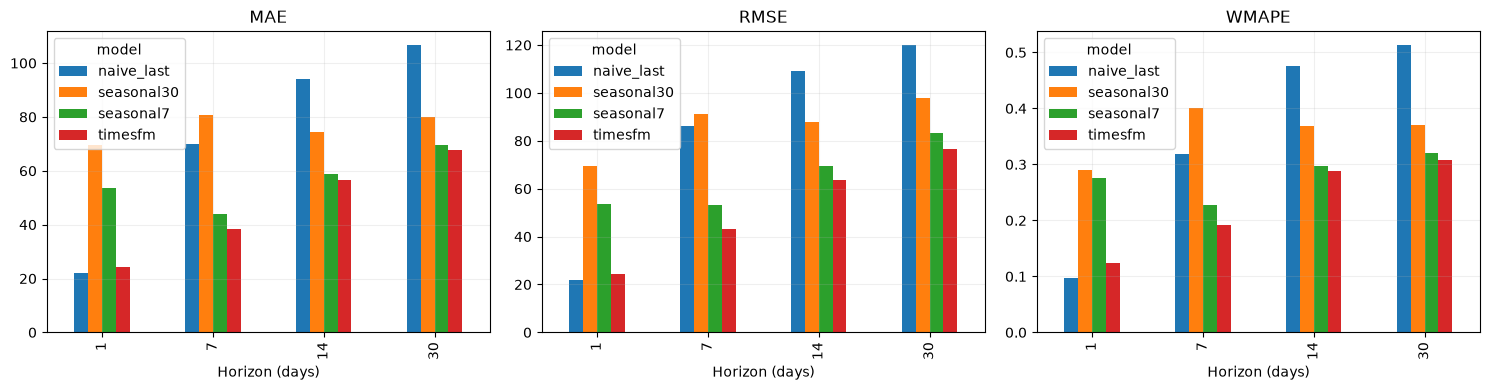

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ['mae', 'rmse', 'wmape']):
    plot_df = backtest_metrics.pivot(index='horizon_days', columns='model', values=metric)
    plot_df.plot(kind='bar', ax=ax)
    ax.set_title(metric.upper())
    ax.set_xlabel('Horizon (days)')
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 7) Forecast Next 30 Days

Generate quantile-aware forecasts (`p50`, `q10`, `q90`) from latest stable history.


In [13]:
latest_pos = len(arr) - 1
latest_date = stable_series['date'].iloc[latest_pos]

context = arr[-cfg.context_len:]
context_start = stable_series['date'].iloc[len(arr) - cfg.context_len]

future_p50, future_quant = run_timesfm_forecast(context=context, start_date=context_start, horizon=cfg.max_horizon)
forecast_dates = pd.date_range(latest_date + pd.Timedelta(days=1), periods=cfg.max_horizon, freq='D')

forecast_df = pd.DataFrame(
    {
        'date': forecast_dates,
        'timesfm_p50_orders': future_p50,
        'timesfm_q10_orders': future_quant[:, 1],
        'timesfm_q90_orders': future_quant[:, 9],
    }
)
forecast_df['uncertainty_band'] = forecast_df['timesfm_q90_orders'] - forecast_df['timesfm_q10_orders']

print('Latest stable date:', latest_date.date())
forecast_df.head(10)

Latest stable date: 2018-09-03


,date,timesfm_p50_orders,timesfm_q10_orders,timesfm_q90_orders,uncertainty_band
0,2018-09-04,47.562210,0.0,105.662315,105.662315
1,2018-09-05,40.344467,0.0,107.340553,107.340553
2,2018-09-06,22.129044,0.0,98.661575,98.661575
3,2018-09-07,7.059799,0.0,91.148468,91.148468
4,2018-09-08,0.000000,0.0,58.159195,58.159195
5,2018-09-09,0.000000,0.0,82.169922,82.169922
6,2018-09-10,55.102692,0.0,158.687622,158.687622
7,2018-09-11,68.733429,0.0,176.790649,176.790649
8,2018-09-12,63.038589,0.0,173.217987,173.217987
9,2018-09-13,45.017715,0.0,160.411774,160.411774


## 8) Warehouse Operations Planning

Translate demand forecasts into operational decisions.

### Workforce planning
- Use `q90` orders for risk-aware staffing.
- Convert orders to labor hours, then to FTE.

### Picking capacity planning
- Convert `q90` orders to required picker-hours.

### Packing station planning
- Convert `q90` orders to minimum stations required.


In [14]:
# Assumptions (calibrate with your warehouse telemetry in production)
LABOR_HOURS_PER_ORDER = 0.045  # average pick+pack labor hours per order
PRODUCTIVE_HOURS_PER_FTE = 7.5
PICKS_PER_PICKER_HOUR = 14.0
PACK_CAPACITY_PER_STATION_PER_DAY = 180.0

ops_plan = forecast_df.copy()

ops_plan['required_labor_hours_q90'] = ops_plan['timesfm_q90_orders'] * LABOR_HOURS_PER_ORDER
ops_plan['fte_required_q90'] = np.ceil(ops_plan['required_labor_hours_q90'] / PRODUCTIVE_HOURS_PER_FTE)

ops_plan['picker_hours_required_q90'] = np.ceil(ops_plan['timesfm_q90_orders'] / PICKS_PER_PICKER_HOUR)
ops_plan['packing_stations_required_q90'] = np.ceil(
    ops_plan['timesfm_q90_orders'] / PACK_CAPACITY_PER_STATION_PER_DAY
)

# Optional service-risk signal under a fixed baseline staffing envelope.
BASELINE_FTE = 8.0
baseline_daily_capacity = BASELINE_FTE * PRODUCTIVE_HOURS_PER_FTE / LABOR_HOURS_PER_ORDER
ops_plan['projected_capacity_gap_q90'] = baseline_daily_capacity - ops_plan['timesfm_q90_orders']
ops_plan['delay_risk_flag'] = np.where(ops_plan['projected_capacity_gap_q90'] < 0, 'high', 'normal')

ops_plan.head(12)

,date,timesfm_p50_orders,timesfm_q10_orders,timesfm_q90_orders,uncertainty_band,required_labor_hours_q90,fte_required_q90,picker_hours_required_q90,packing_stations_required_q90,projected_capacity_gap_q90,delay_risk_flag
0,2018-09-04,47.562210,0.0,105.662315,105.662315,4.754805,1.0,8.0,1.0,1227.671021,normal
1,2018-09-05,40.344467,0.0,107.340553,107.340553,4.830325,1.0,8.0,1.0,1225.992798,normal
2,2018-09-06,22.129044,0.0,98.661575,98.661575,4.439771,1.0,8.0,1.0,1234.671753,normal
3,2018-09-07,7.059799,0.0,91.148468,91.148468,4.101681,1.0,7.0,1.0,1242.184937,normal
4,2018-09-08,0.000000,0.0,58.159195,58.159195,2.617164,1.0,5.0,1.0,1275.174194,normal
5,2018-09-09,0.000000,0.0,82.169922,82.169922,3.697647,1.0,6.0,1.0,1251.163452,normal
6,2018-09-10,55.102692,0.0,158.687622,158.687622,7.140943,1.0,12.0,1.0,1174.645752,normal
7,2018-09-11,68.733429,0.0,176.790649,176.790649,7.955580,2.0,13.0,1.0,1156.542725,normal
8,2018-09-12,63.038589,0.0,173.217987,173.217987,7.794810,2.0,13.0,1.0,1160.115356,normal
9,2018-09-13,45.017715,0.0,160.411774,160.411774,7.218530,1.0,12.0,1.0,1172.921631,normal


In [15]:
# KPI summary for planning horizon
kpi_summary = pd.DataFrame(
    {
        'metric': [
            'forecast_horizon_days',
            'avg_daily_orders_p50',
            'avg_daily_orders_q90',
            'max_daily_orders_q90',
            'avg_fte_required_q90',
            'max_fte_required_q90',
            'high_delay_risk_days',
        ],
        'value': [
            len(ops_plan),
            float(ops_plan['timesfm_p50_orders'].mean()),
            float(ops_plan['timesfm_q90_orders'].mean()),
            float(ops_plan['timesfm_q90_orders'].max()),
            float(ops_plan['fte_required_q90'].mean()),
            float(ops_plan['fte_required_q90'].max()),
            int((ops_plan['delay_risk_flag'] == 'high').sum()),
        ],
    }
)

kpi_summary

,metric,value
0,forecast_horizon_days,30.000000
1,avg_daily_orders_p50,48.883816
2,avg_daily_orders_q90,165.213669
3,max_daily_orders_q90,288.431183
4,avg_fte_required_q90,1.466667
5,max_fte_required_q90,2.000000
6,high_delay_risk_days,0.000000


## 9) Save Deliverables

Outputs written to `artifacts/warehouse_order_volume_timesfm/`:

- `backtest_metrics.csv`
- `backtest_detail.csv`
- `forecast_next_30_days.csv`
- `warehouse_operations_plan.csv`
- `kpi_summary.csv`


In [16]:
backtest_metrics_path = ART_DIR / 'backtest_metrics.csv'
backtest_detail_path = ART_DIR / 'backtest_detail.csv'
forecast_path = ART_DIR / 'forecast_next_30_days.csv'
ops_path = ART_DIR / 'warehouse_operations_plan.csv'
kpi_path = ART_DIR / 'kpi_summary.csv'

backtest_metrics.to_csv(backtest_metrics_path, index=False)
backtest_detail.to_csv(backtest_detail_path, index=False)
forecast_df.to_csv(forecast_path, index=False)
ops_plan.to_csv(ops_path, index=False)
kpi_summary.to_csv(kpi_path, index=False)

print('Saved artifacts:')
for p in [backtest_metrics_path, backtest_detail_path, forecast_path, ops_path, kpi_path]:
    print('-', p)

backtest_metrics

Saved artifacts:
- /home/ahmad/AI/Github/google-TimesFM-implementation/artifacts/warehouse_order_volume_timesfm/backtest_metrics.csv
- /home/ahmad/AI/Github/google-TimesFM-implementation/artifacts/warehouse_order_volume_timesfm/backtest_detail.csv
- /home/ahmad/AI/Github/google-TimesFM-implementation/artifacts/warehouse_order_volume_timesfm/forecast_next_30_days.csv
- /home/ahmad/AI/Github/google-TimesFM-implementation/artifacts/warehouse_order_volume_timesfm/warehouse_operations_plan.csv
- /home/ahmad/AI/Github/google-TimesFM-implementation/artifacts/warehouse_order_volume_timesfm/kpi_summary.csv


,horizon_days,model,mae,rmse,wmape
0,1,naive_last,22.000000,22.000000,0.096581
3,1,timesfm,24.290871,24.290871,0.124074
2,1,seasonal7,53.500000,53.500000,0.275738
1,1,seasonal30,69.500000,69.500000,0.289260
7,7,timesfm,38.245860,43.039847,0.192119
6,7,seasonal7,43.928571,53.245970,0.227852
4,7,naive_last,70.000000,86.200267,0.318886
5,7,seasonal30,80.714287,91.327629,0.400533
11,14,timesfm,56.735686,63.681149,0.288939
10,14,seasonal7,58.857142,69.601450,0.298024


## Assumptions, Limitations, and Production Next Steps

### Assumptions

- Historical order timestamps are representative of warehouse inbound workload.
- Capacity coefficients (labor time, picks/hour, pack throughput) are fixed.

### Limitations

- No explicit external regressors (promotions, ad spend, holidays, weather).
- No sub-warehouse or SKU-level decomposition.
- Final operational policy is heuristic, not optimization-based.

### Production next steps

- Add feature store covariates (campaigns, assortment, holiday/event calendar).
- Forecast at multi-level hierarchy: warehouse -> zone -> station.
- Integrate optimization solver for shift design and station allocation.
- Monitor drift and decision impact (delay %, SLA breach, overtime hours).
